In [1]:
from asyncio.windows_events import NULL
from operator import index

import drop
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## 1. Load Data Using Pandas.

In [2]:
# Read the dataset from the csv file using the pandas library.
df = pd.read_csv("googleplaystore.csv")


### 1.1 Check for successful loading of the dataset.

In [3]:
# Get the first 5 fields and records of the dataset.
df.head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [4]:
# Get the last 5 fields and records of the dataset.
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


## 2. Check for null values in the data.

In [5]:
# Check if there are any 'null' records in any of the records belonging to any of the fields.
print(df.isnull().sum().sort_values(ascending=False))
print("Total number of null values: ", df.isnull().sum().sum())

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
Installs             0
Last Updated         0
Genres               0
dtype: int64
Total number of null values:  1487


## 3. Drop records with null values in any of the columns.

In [6]:
# Drop the null values.
df = df.dropna()
print(df.isnull().sum())
print("Total number of null values: ", df.isnull().sum().sum())

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64
Total number of null values:  0


## 4. Formatting variables into correct data types.

In [7]:
df['Category'] = df['Category'].astype('category') #Set category records as category.
df['Reviews'] = df['Reviews'].astype(int) #Set reviews records as integers.
df['Installs'] = df['Installs'].str.replace('+','').str.replace(',', '').astype(int) #Set installs records as Integers.
df['Price'] = df['Price'].str.replace('$','').astype(float) #Set price records as float.
df['Content Rating'] = df['Content Rating'].astype('category') #Set content rating as category.
df['Genres'] = df['Genres'].astype('category') #Set genres as category.
df['Last Updated'] = pd.to_datetime(df['Last Updated']) #Set last updated to datetime.
df['Current Ver'] = df['Current Ver'].replace('Varies with device', np.nan).astype(object) #Set current ver as object.
df['Android Ver'] = df['Android Ver'].replace('Varies with device', np.nan).astype(object) #Set android ver as object.
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')


In [8]:
#Format the size field and its records.
df['Size'] = df['Size'].replace('Varies with device', np.nan)

df['Size'] = df['Size'].apply(lambda x: float(str(x).replace('M', '')) if 'M' in str(x)
                              else float(str(x).replace('k','')) / 1000 if 'k' in str(x)
                              else np.nan)

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 9360 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9360 non-null   str           
 1   Category        9360 non-null   category      
 2   Rating          9360 non-null   float64       
 3   Reviews         9360 non-null   int64         
 4   Size            7723 non-null   float64       
 5   Installs        9360 non-null   int64         
 6   Type            9360 non-null   str           
 7   Price           9360 non-null   float64       
 8   Content Rating  9360 non-null   category      
 9   Genres          9360 non-null   category      
 10  Last Updated    9360 non-null   datetime64[us]
 11  Current Ver     7945 non-null   object        
 12  Android Ver     8041 non-null   object        
dtypes: category(3), datetime64[us](1), float64(3), int64(2), object(2), str(2)
memory usage: 833.0+ KB


### 4.1 Sanity Checks.

In [10]:
print("Minimum rating: ", df['Rating'].min())
print("Maximum rating: ", df['Rating'].max())

Minimum rating:  1.0
Maximum rating:  5.0


In [11]:
print('Number of installs: ', df['Installs'].count())
print('Number of reviews: ', df['Reviews'].count())
print('Number of ratings: ', df['Rating'].count())

Number of installs:  9360
Number of reviews:  9360
Number of ratings:  9360


In [12]:
print(df[['Type','Price']].drop_duplicates()) #Drop duplicates on the type and price fields.

       Type  Price
0      Free   0.00
234    Paid   4.99
427    Paid   3.99
477    Paid   6.99
481    Paid   7.99
...     ...    ...
9465   Paid   2.95
9490   Paid   2.90
9566   Paid   1.97
9869   Paid   2.56
10785  Paid   1.20

[73 rows x 2 columns]


## 5. Performing univariate analysis

In [13]:
import seaborn as sns #Import seaborn library.
import matplotlib.pyplot as plt #Import matplot library.

### 5.1 Outlier treatment.

In [14]:
#Get different quantiles of the install variable.
print('10th Quantile: ', df['Installs'].quantile(0.1))
print('25th Quantile: ', df['Installs'].quantile(0.25))
print('50th Quantile: ', df['Installs'].quantile(0.50))
print('70th Quantile: ', df['Installs'].quantile(0.70))
print('90th Quantile: ', df['Installs'].quantile(0.90))
print('99th Quantile: ', df['Installs'].quantile(0.99))

#Filter out records not meeting specific conditions.
df = df[
    (df['Price'] <= 200) &
    (df['Installs'] <= 2000000) &
    (df['Reviews'] <= 2000000) &
    (df['Rating'] >= 1) &
    (df['Rating'] <= 5) &
    (df['Rating'].notna())
]

10th Quantile:  1000.0
25th Quantile:  10000.0
50th Quantile:  500000.0
70th Quantile:  5000000.0
90th Quantile:  10000000.0
99th Quantile:  500000000.0


### 5.2 Boxplot for price.

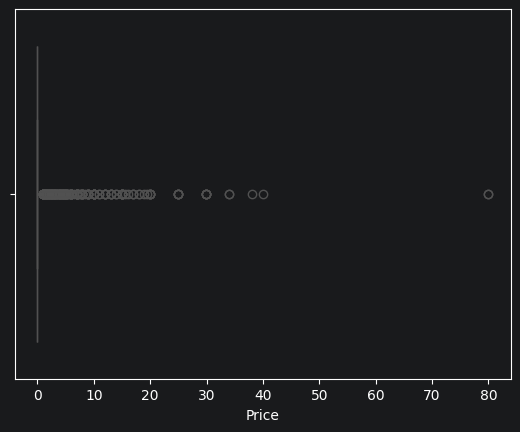

In [15]:
sns.boxplot(x = 'Price', data = df)
plt.show()

### 5.3 Boxplot for reviews.

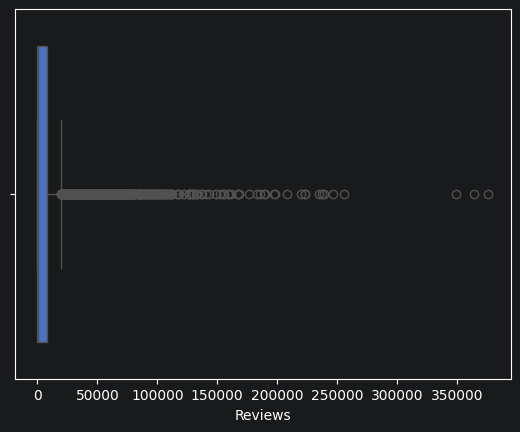

In [16]:
sns.boxplot(x = 'Reviews', data = df)
plt.show()

### 5.4 Histogram for rating.

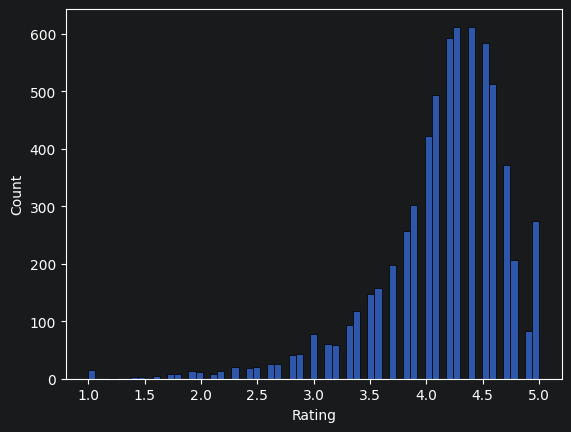

In [17]:
sns.histplot(data = df, x = 'Rating')
plt.show()

### 5.5 Histogram for size

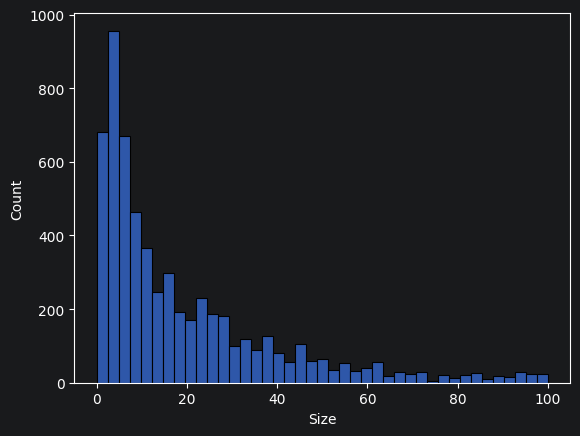

In [18]:
sns.histplot(data = df, x = 'Size')
plt.show()

## 6. Bivariate analysis

### 6.1 Scatter plot for Rating vs. Price.

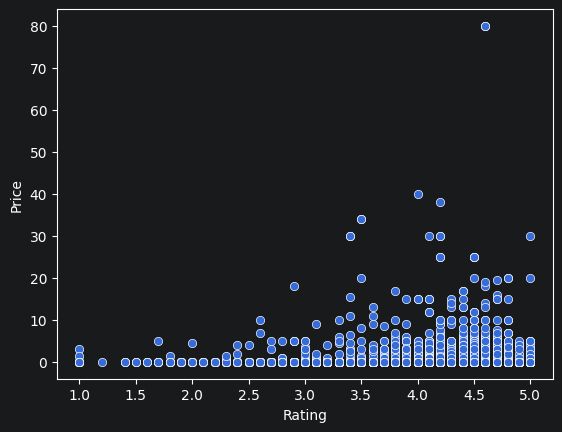

In [19]:
sns.scatterplot(data = df, x = 'Rating', y = 'Price')
plt.show()

### 6.2 Scatter plot for Rating vs. Size.

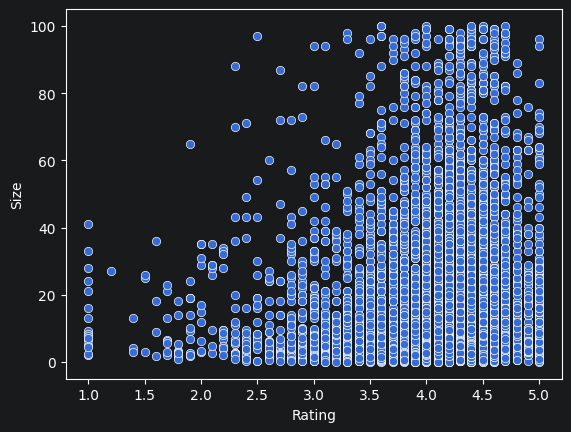

In [20]:
sns.scatterplot(data = df, x = 'Rating', y = 'Size')
plt.show()

### 6.3 Scatter plot for Rating vs. Reviews.

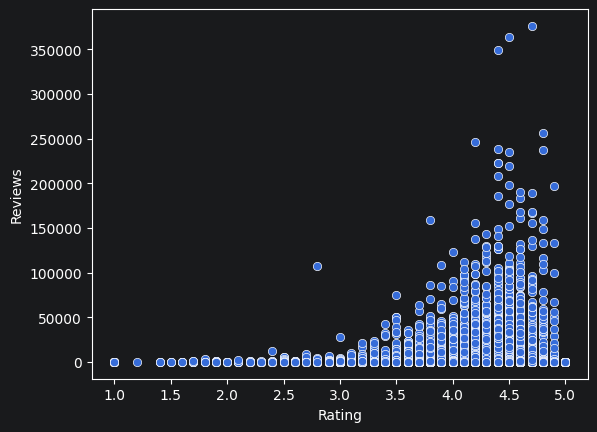

In [21]:
sns.scatterplot(data = df, x = 'Rating', y = 'Reviews')
plt.show()

### 6.4 Boxplot for Rating vs. Content Rating.

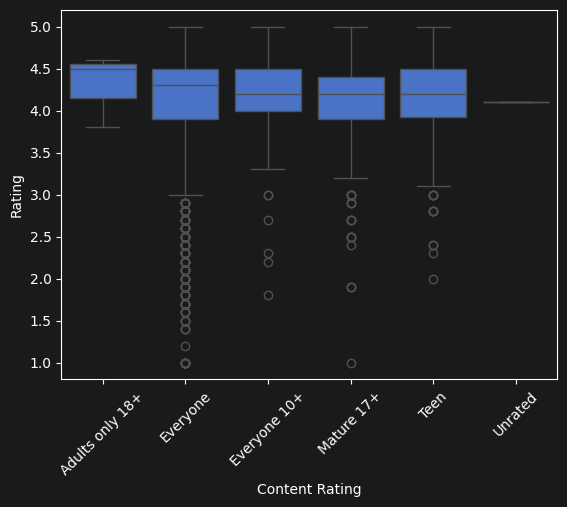

In [22]:
sns.boxplot(data = df, x = 'Content Rating', y = 'Rating')
plt.xticks(rotation = 45)
plt.show()

### 6.5 Boxplot for Rating vs. Category.

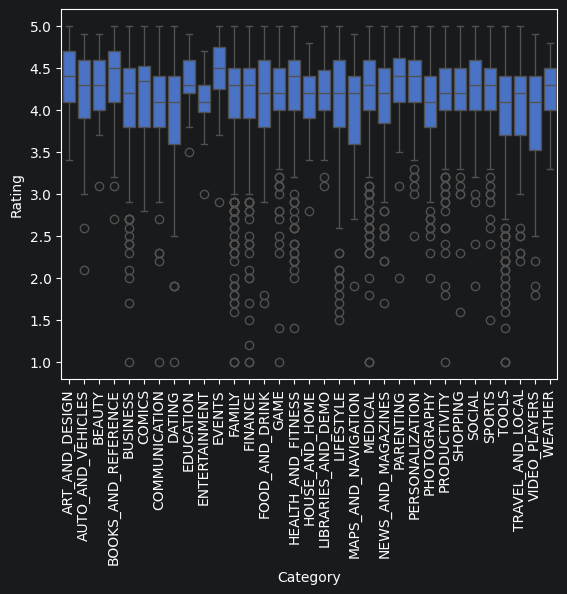

In [23]:
sns.boxplot(data = df, x = 'Category', y = 'Rating')
plt.xticks(rotation = 90)
plt.show()

## 7. Data preprocessing and formatting.

In [24]:
inp1 = df #creating a copy of a dataframe

In [25]:
print(inp1.head())

                                              App        Category  Rating  \
0  Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                             Coloring book moana  ART_AND_DESIGN     3.9   
4           Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   
5                      Paper flowers instructions  ART_AND_DESIGN     4.4   
6         Smoke Effect Photo Maker - Smoke Editor  ART_AND_DESIGN     3.8   

   Reviews  Size  Installs  Type  Price Content Rating  \
0      159  19.0     10000  Free    0.0       Everyone   
1      967  14.0    500000  Free    0.0       Everyone   
4      967   2.8    100000  Free    0.0       Everyone   
5      167   5.6     50000  Free    0.0       Everyone   
6      178  19.0     50000  Free    0.0       Everyone   

                      Genres Last Updated Current Ver   Android Ver  
0               Art & Design   2018-01-07       1.0.0  4.0.3 and up  
1  Art & Design;Pretend Play   2018-01-15       

In [26]:
df['Installs_log'] = np.log1p(inp1['Installs']) #Reducing the skewness of the Installs records using the np.log1p function.
print(df['Installs_log'].unique())

[ 9.21044037 13.12236538 11.51293546 10.81979828 13.81551156  8.51739317
  6.90875478  4.61512052  6.2166061   2.39789527  1.79175947  3.93182563
  0.69314718]


In [27]:
df['Reviews_log'] = np.log1p(inp1['Reviews']) #Reducing the skewness of the Reviews records using the np.log1p function.
print(df['Reviews_log'].unique())

[5.07517382 6.87523209 5.12396398 ... 6.78671695 6.4035742  7.08673793]


In [28]:
inp2 = pd.get_dummies(df[['Category', 'Content Rating', 'Genres']], drop_first=False).astype(int)
print(inp2) #One-hot encoding

       Category_ART_AND_DESIGN  Category_AUTO_AND_VEHICLES  Category_BEAUTY  \
0                            1                           0                0   
1                            1                           0                0   
4                            1                           0                0   
5                            1                           0                0   
6                            1                           0                0   
...                        ...                         ...              ...   
10833                        0                           0                0   
10834                        0                           0                0   
10836                        0                           0                0   
10837                        0                           0                0   
10839                        0                           0                0   

       Category_BOOKS_AND_REFERENCE  Category_BUSIN

## 8. Train-test split the dataset.

In [29]:
df_copy = df[['Installs_log', 'Rating']]

df_copy_grouped = df_copy.groupby(['Installs_log'])['Rating'].mean().reset_index()

print(df_copy_grouped)

# Categorical columns
cat_cols = df_copy_grouped.select_dtypes(include=['category'])

# Numerical columns
num_cols = df_copy_grouped.select_dtypes(include=['int64', 'float64'])

print("Categorical Columns:", cat_cols.columns)

print("\nNumerical Columns:", num_cols.columns)

#cat_encoded = pd.get_dummies(cat_cols, drop_first=True)

#df_final = pd.concat([cat_encoded, num_cols], axis=1)

df_train, df_test = train_test_split(num_cols, test_size = 0.3, random_state = 42) #Creating train and test dataframes using the train_test_split function.
print(df_train.shape, df_test.shape)


    Installs_log    Rating
0       0.693147  5.000000
1       1.791759  4.611111
2       2.397895  4.624638
3       3.931826  4.419643
4       4.615121  4.363636
5       6.216606  4.176617
6       6.908755  4.068362
7       8.517393  4.026168
8       9.210440  4.040637
9      10.819798  4.051183
10     11.512935  4.110531
11     13.122365  4.168156
12     13.815512  4.220939
Categorical Columns: Index([], dtype='str')

Numerical Columns: Index(['Installs_log', 'Rating'], dtype='str')
(9, 2) (4, 2)


In [30]:

X_train = df_train.drop('Rating', axis=1)
y_train = df_train['Rating']

X_test = df_test.drop('Rating', axis=1)
y_test = df_test['Rating']


## 9. Build the model

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

model_score_train = model.score(X_train, y_train)
model_score_test = model.score(X_test, y_test)

print('Training Score: ', round(model_score_train,2))
print('Test Score: ', round(model_score_test,2))

Training Score:  0.54
Test Score:  0.58


## 10. Make predictions on the test set.

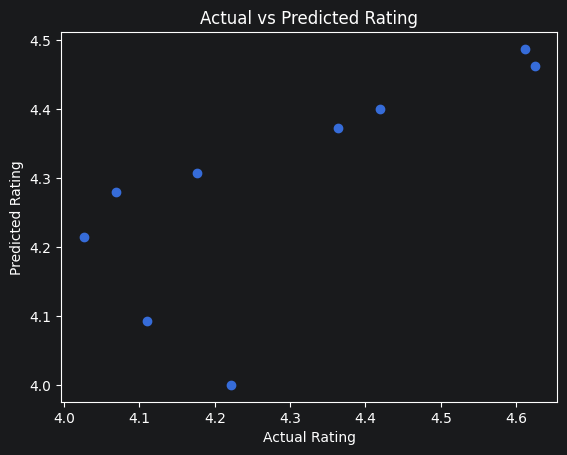

In [32]:
y_prediction = model.predict(X_train)
plt.scatter(y_train, y_prediction)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Rating')
plt.show()